In [1]:
!pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 4.6 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\chand\AppData\Roaming\nltk_data...


True

In [4]:
df = pd.read_csv("FAKE_NEWS_NET.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())


Dataset Shape: (23196, 5)

Columns:
Index(['title', 'news_url', 'source_domain', 'tweet_num', 'real'], dtype='str')

First 5 rows:
                                               title  \
0  Kandi Burruss Explodes Over Rape Accusation on...   
1  People's Choice Awards 2018: The best red carp...   
2  Sophia Bush Sends Sweet Birthday Message to 'O...   
3  Colombian singer Maluma sparks rumours of inap...   
4  Gossip Girl 10 Years Later: How Upper East Sid...   

                                            news_url        source_domain  \
0  http://toofab.com/2017/05/08/real-housewives-a...           toofab.com   
1  https://www.today.com/style/see-people-s-choic...        www.today.com   
2  https://www.etonline.com/news/220806_sophia_bu...     www.etonline.com   
3  https://www.dailymail.co.uk/news/article-33655...  www.dailymail.co.uk   
4  https://www.zerchoo.com/entertainment/gossip-g...      www.zerchoo.com   

   tweet_num  real  
0         42     1  
1          0     1  
2     

In [5]:
required_columns = [
    "title",
    "news_url",
    "source_domain",
    "tweet_num",
    "real"
]

df = df[required_columns]


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64

Duplicate Rows:
137


In [7]:
df = df.drop_duplicates()

In [8]:
df["title"] = df["title"].fillna("")
df["news_url"] = df["news_url"].fillna("")
df["source_domain"] = df["source_domain"].fillna("unknown")

# Numeric column
df["tweet_num"] = pd.to_numeric(
    df["tweet_num"],
    errors="coerce"
)

df["tweet_num"] = df["tweet_num"].fillna(
    df["tweet_num"].median()
)

# Target
df = df.dropna(subset=["real"])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
title            0
news_url         0
source_domain    0
tweet_num        0
real             0
dtype: int64



Target Distribution:
real
1    17396
0     5663
Name: count, dtype: int64


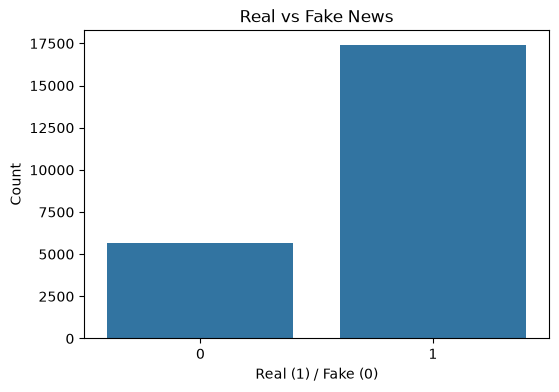

In [9]:
print("\nTarget Distribution:")
print(df["real"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=df["real"])
plt.title("Real vs Fake News")
plt.xlabel("Real (1) / Fake (0)")
plt.ylabel("Count")
plt.show()

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove HTML
    text = re.sub(r"<.*?>", "", text)

    # remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    words = text.split()

    # stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [11]:
print("\nCleaning text...")

df["title_clean"] = df["title"].apply(clean_text)
df["url_clean"] = df["news_url"].apply(clean_text)
df["domain_clean"] = df["source_domain"].apply(clean_text)


Cleaning text...


In [12]:
df["combined_text"] = (
    df["title_clean"] + " " +
    df["url_clean"] + " " +
    df["domain_clean"]
)

In [13]:
df = df[df["combined_text"].str.strip() != ""]

In [14]:
X = df[
    [
        "title_clean",
        "url_clean",
        "domain_clean",
        "tweet_num"
    ]
]

y = df["real"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))



Training Samples: 18446
Testing Samples: 4612


In [16]:
preprocessor = ColumnTransformer(

    transformers=[

        # Title - word TF-IDF
        (
            "title_word",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            ),
            "title_clean"
        ),

        # Title - character TF-IDF
        (
            "title_char",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(3, 5),
                max_features=30000,
                min_df=2,
                sublinear_tf=True
            ),
            "title_clean"
        ),

        # URL
        (
            "url",
            TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 2),
                max_features=20000,
                min_df=2
            ),
            "url_clean"
        ),

        # Source domain
        (
            "domain",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(2, 5),
                max_features=10000
            ),
            "domain_clean"
        ),

        # Tweet count
        (
            "tweet",
            StandardScaler(),
            ["tweet_num"]
        )
    ],

    remainder="drop"
)

In [17]:
logistic_model = Pipeline([

    ("features", preprocessor),

    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            C=2
        )
    )
])


print("\nTraining Logistic Regression...")

logistic_model.fit(X_train, y_train)

pred_lr = logistic_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, pred_lr)

print("\nLogistic Regression Accuracy:",
      accuracy_lr * 100, "%")


Training Logistic Regression...

Logistic Regression Accuracy: 85.94969644405897 %


In [18]:
svm_model = Pipeline([

    ("features", preprocessor),

    (
        "classifier",
        LinearSVC(
            C=1.5
        )
    )
])


print("\nTraining Linear SVM...")

svm_model.fit(X_train, y_train)

pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, pred_svm)

print("\nLinear SVM Accuracy:",
      accuracy_svm * 100, "%")


Training Linear SVM...


C:\Users\chand\Desktop\Project AIML\ML Project\venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Linear SVM Accuracy: 85.53772766695576 %


In [19]:
# Naive Bayes does not work directly with StandardScaler
# numeric feature, so use only text/domain for this model.

nb_features = ColumnTransformer(

    transformers=[

        (
            "title",
            TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=50000,
                min_df=2
            ),
            "title_clean"
        ),

        (
            "url",
            TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=20000,
                min_df=2
            ),
            "url_clean"
        ),

        (
            "domain",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(2, 5),
                max_features=10000
            ),
            "domain_clean"
        )
    ]
)


nb_model = Pipeline([

    ("features", nb_features),

    (
        "classifier",
        MultinomialNB(alpha=0.1)
    )
])


print("\nTraining Naive Bayes...")

nb_model.fit(X_train, y_train)

pred_nb = nb_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, pred_nb)

print("\nNaive Bayes Accuracy:",
      accuracy_nb * 100, "%")



Training Naive Bayes...

Naive Bayes Accuracy: 84.95229835212488 %


In [20]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_svm,
        accuracy_nb
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

print("\n================ MODEL COMPARISON ================")
print(
    results[
        ["Model", "Accuracy (%)"]
    ].sort_values(
        "Accuracy (%)",
        ascending=False
    )
)


================ MODEL COMPARISON ================
                 Model  Accuracy (%)
0  Logistic Regression     85.949696
1           Linear SVM     85.537728
2          Naive Bayes     84.952298


In [21]:
models = {
    "Logistic Regression": (logistic_model, accuracy_lr),
    "Linear SVM": (svm_model, accuracy_svm),
    "Naive Bayes": (nb_model, accuracy_nb)
}

best_model_name = max(
    models,
    key=lambda x: models[x][1]
)

best_model = models[best_model_name][0]
best_accuracy = models[best_model_name][1]


print("\n======================================")
print("BEST MODEL:", best_model_name)
print("BEST ACCURACY:", best_accuracy * 100, "%")
print("======================================")


BEST MODEL: Logistic Regression
BEST ACCURACY: 85.94969644405897 %


In [22]:
best_prediction = best_model.predict(X_test)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_prediction,
        target_names=[
            "Fake News",
            "Real News"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

   Fake News       0.80      0.57      0.66      1133
   Real News       0.87      0.95      0.91      3479

    accuracy                           0.86      4612
   macro avg       0.84      0.76      0.79      4612
weighted avg       0.85      0.86      0.85      4612



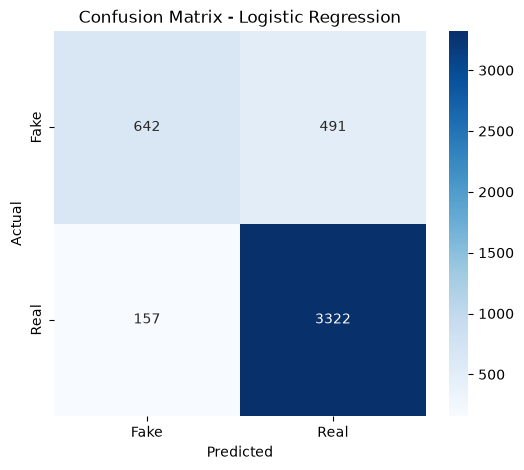

In [23]:
cm = confusion_matrix(
    y_test,
    best_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Fake",
        "Real"
    ],
    yticklabels=[
        "Fake",
        "Real"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    "Confusion Matrix - " + best_model_name
)

plt.show()

In [24]:
precision = precision_score(
    y_test,
    best_prediction
)

recall = recall_score(
    y_test,
    best_prediction
)

f1 = f1_score(
    y_test,
    best_prediction
)

print("\nPerformance:")
print("Accuracy :", round(best_accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")


Performance:
Accuracy : 85.95 %
Precision: 87.12 %
Recall   : 95.49 %
F1 Score : 91.11 %


In [25]:
import joblib

joblib.dump(
    best_model,
    "fake_news_model.pkl"
)

print("\nModel saved as fake_news_model.pkl")



Model saved as fake_news_model.pkl


In [28]:
import pickle

with open("fake_news_model.pkl", "wb") as f:
    pickle.dump(logistic_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("Both files saved successfully!")

Both files saved successfully!
